# 02: pLLPS-Enriched Functional Groups

This notebook identifies functional groups of membrane proteins that are enriched in pLLPS scores.

**Workflow:**
1. Load pLLPS data from notebook 01
2. Classify membrane proteins by functional group
3. Analyze pLLPS enrichment within each group
4. Visualize distributions and enrichment statistics
5. Save results for downstream analysis

**Outputs:**
- `functional_groups_with_pllps.csv`: Classified proteins with pLLPS scores
- `functional_enrichment_stats.csv`: Enrichment statistics per group
- `pllps_enriched_groups.json`: List of enriched groups
- `functional_groups_pllps_enrichment.png`: Visualization

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import llps_functions as lf
import json
import importlib
from pathlib import Path
from scipy.stats import chi2_contingency

# Reload module
importlib.reload(lf)

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Constants
HIGH_THRESHOLD = 0.7  # pLLPS threshold for 'high' classification
ENRICHMENT_THRESHOLD = 1.2  # Fold-enrichment threshold

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load and Prepare pLLPS Data

In [5]:
# Load datasets
df_full = lf.load_analysis_result('full_dataset', format='csv')

print(f"\n📊 Data Loaded:")
print(f"   Total proteins: {len(df_full)}")
print(f"   pLLPS scores available: {df_full['p(LLPS)'].notna().sum()}")
print(f"   Mean pLLPS: {df_full['p(LLPS)'].mean():.3f}")
print(f"   High pLLPS (>{HIGH_THRESHOLD}): {(df_full['p(LLPS)'] > HIGH_THRESHOLD).sum()}")

✅ Loaded CSV from: results/full_dataset.csv (20366 rows)

📊 Data Loaded:
   Total proteins: 20366
   pLLPS scores available: 20366
   Mean pLLPS: 0.488
   High pLLPS (>0.7): 6568


## 2. Identify Functional Groups of Membrane Proteins

In [6]:
# Classify proteins by functional group using YAML-based classifier
print("\n🔍 Classifying proteins by functional group...")


def classify_proteins_by_function(df):
    """Classify proteins into functional groups using parse_function_categories.

    Uses the YAML-defined regex patterns from
    data/functional_classification_terms.yaml (20 categories) instead of a
    small hard-coded keyword list.  The first matched category (order follows
    the YAML, so more-specific entries come first) is used as the primary
    'Functional Group'.  All matched categories are stored in
    'All_Functional_Groups' for inspection.
    """
    df = df.copy()

    df['All_Functional_Groups'] = df.apply(
        lambda row: lf.parse_function_categories(
            row.get('Function [CC]', ''),
            row.get('Protein names', '')
        ),
        axis=1
    )

    # Primary group: first match (most specific given YAML ordering), else 'Other'
    df['Functional Group'] = df['All_Functional_Groups'].apply(
        lambda cats: cats[0] if cats else 'Other'
    )

    return df


# Apply classification
membrane_with_functions = classify_proteins_by_function(df_full.copy())

# Print summary
print("\n📋 Functional Group Distribution:")
group_counts = membrane_with_functions['Functional Group'].value_counts()
for group, count in group_counts.items():
    pct = 100 * count / len(membrane_with_functions)
    print(f"   {group}: {count} ({pct:.1f}%)")



🔍 Classifying membrane proteins by functional group...

📋 Functional Group Distribution:
   Other: 15393 (75.6%)
   Enzyme: 2840 (13.9%)
   Structural: 1443 (7.1%)
   Ion Channel: 334 (1.6%)
   Transporter: 313 (1.5%)
   Receptor Tyrosine Kinase: 26 (0.1%)
   GPCR: 17 (0.1%)


## 3. Analyze pLLPS Enrichment Within Functional Groups

In [7]:
# Statistical analysis of pLLPS by functional group
print("\n📈 Statistical Enrichment Analysis:")
print("="*70)

enrichment_results = []

# Overall statistics
overall_high = (membrane_with_functions['p(LLPS)'] > HIGH_THRESHOLD).sum()
overall_pct = 100 * overall_high / len(membrane_with_functions)

print(f"\nOverall high pLLPS rate: {overall_high}/{len(membrane_with_functions)} ({overall_pct:.1f}%)")

for group in sorted(membrane_with_functions['Functional Group'].unique()):
    group_data = membrane_with_functions[membrane_with_functions['Functional Group'] == group]
    
    if len(group_data) == 0:
        continue
    
    # Statistics
    n_total = len(group_data)
    n_high = (group_data['p(LLPS)'] > HIGH_THRESHOLD).sum()
    pct_high = 100 * n_high / n_total if n_total > 0 else 0
    mean_pllps = group_data['p(LLPS)'].mean()
    median_pllps = group_data['p(LLPS)'].median()
    
    # Enrichment fold-change
    enrichment = (pct_high / 100) / (overall_pct / 100) if overall_pct > 0 else 0
    
    # Chi-squared test for independence
    contingency_table = np.array([
        [n_high, n_total - n_high],
        [overall_high, len(membrane_with_functions) - overall_high]
    ])
    
    try:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    except:
        p_value = 1.0
        chi2 = 0
    
    enrichment_results.append({
        'Functional Group': group,
        'Count': n_total,
        'High pLLPS': n_high,
        'Percent High': pct_high,
        'Mean pLLPS': mean_pllps,
        'Median pLLPS': median_pllps,
        'Enrichment': enrichment,
        'Chi2': chi2,
        'P-value': p_value
    })
    
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"\n{group}:")
    print(f"   N={n_total}, High pLLPS: {n_high} ({pct_high:.1f}%)")
    print(f"   Mean: {mean_pllps:.3f}, Median: {median_pllps:.3f}")
    print(f"   Enrichment: {enrichment:.2f}x (p={p_value:.2e}) {sig}")

enrichment_df = pd.DataFrame(enrichment_results)
enrichment_df = enrichment_df.sort_values('Enrichment', ascending=False)

print("\n" + "="*70)
print(f"\n🎯 Groups significantly enriched in pLLPS (p<0.05):")
enriched_groups = enrichment_df[enrichment_df['P-value'] < 0.05]
for _, row in enriched_groups.iterrows():
    print(f"   • {row['Functional Group']}: {row['Enrichment']:.2f}x (p={row['P-value']:.2e})")


📈 Statistical Enrichment Analysis:

Overall high pLLPS rate: 6568/20366 (32.2%)

Enzyme:
   N=2840, High pLLPS: 707 (24.9%)
   Mean: 0.428, Median: 0.290
   Enrichment: 0.77x (p=2.93e-15) ***

GPCR:
   N=17, High pLLPS: 1 (5.9%)
   Mean: 0.269, Median: 0.200
   Enrichment: 0.18x (p=3.89e-02) *

Ion Channel:
   N=334, High pLLPS: 81 (24.3%)
   Mean: 0.428, Median: 0.280
   Enrichment: 0.75x (p=2.32e-03) **

Other:
   N=15393, High pLLPS: 5184 (33.7%)
   Mean: 0.498, Median: 0.380
   Enrichment: 1.04x (p=4.59e-03) **

Receptor Tyrosine Kinase:
   N=26, High pLLPS: 12 (46.2%)
   Mean: 0.628, Median: 0.665
   Enrichment: 1.43x (p=1.92e-01) ns

Structural:
   N=1443, High pLLPS: 561 (38.9%)
   Mean: 0.557, Median: 0.500
   Enrichment: 1.21x (p=2.50e-07) ***

Transporter:
   N=313, High pLLPS: 22 (7.0%)
   Mean: 0.293, Median: 0.200
   Enrichment: 0.22x (p=3.65e-21) ***


🎯 Groups significantly enriched in pLLPS (p<0.05):
   • Structural: 1.21x (p=2.50e-07)
   • Other: 1.04x (p=4.59e-03)
  

## 4. Visualize pLLPS Distributions by Functional Group

/tmp/ipykernel_69257/2669922211.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 0].boxplot(data_by_group, labels=group_order)



✅ Visualization saved: results/functional_groups_pllps_enrichment.png


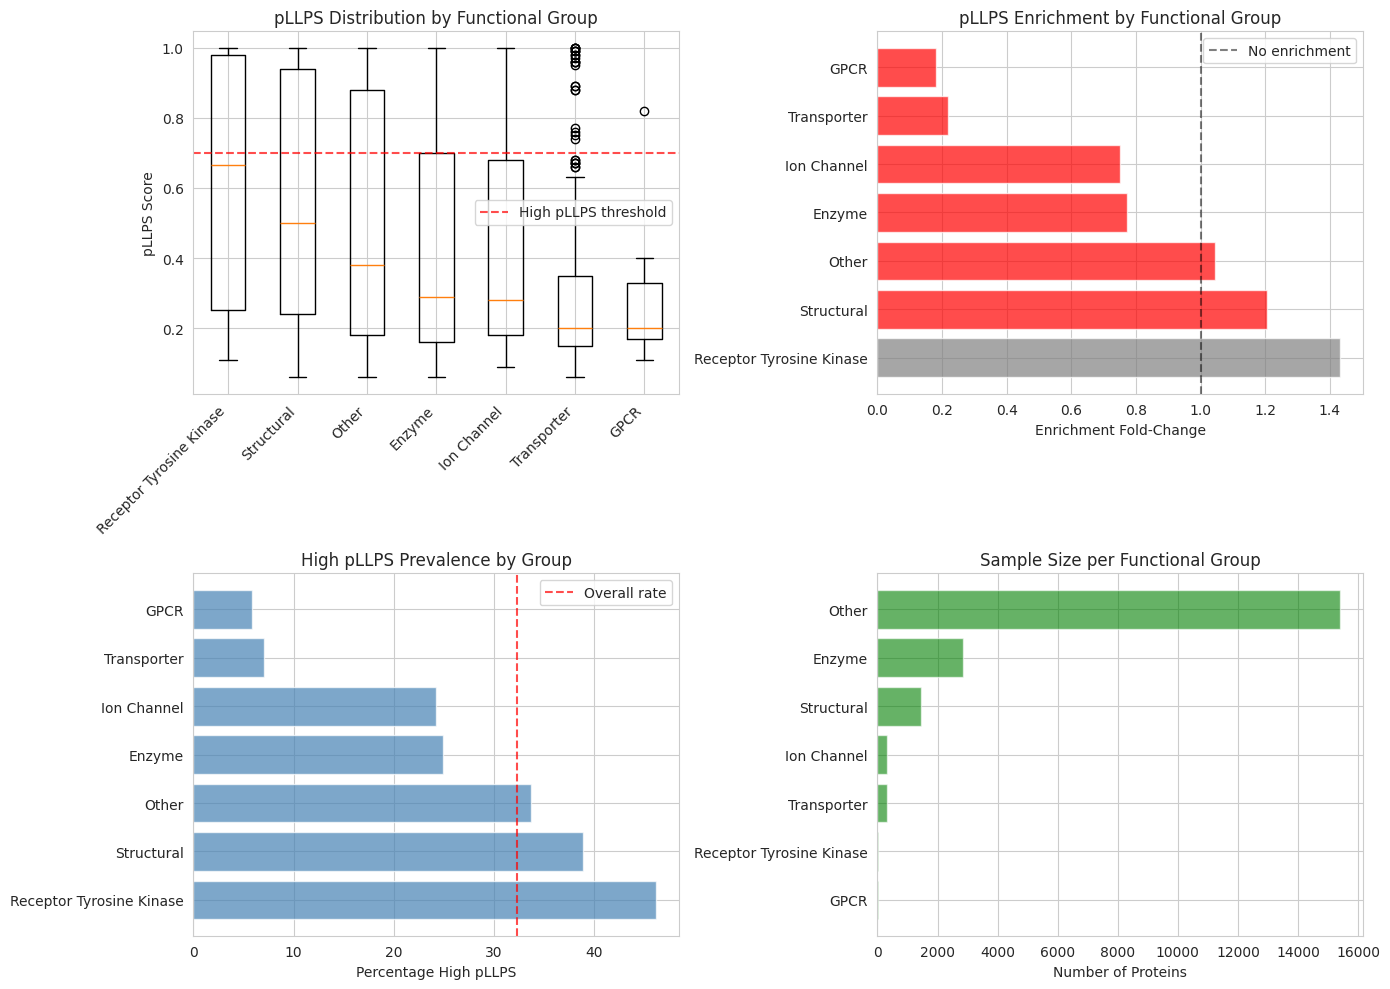

In [8]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Box plot of pLLPS by functional group (sorted by median)
enriched_sorted = enrichment_df.sort_values('Median pLLPS', ascending=False)
group_order = enriched_sorted['Functional Group'].tolist()

data_by_group = [membrane_with_functions[membrane_with_functions['Functional Group'] == g]['p(LLPS)'].values 
                  for g in group_order]

bp = axes[0, 0].boxplot(data_by_group, labels=group_order)
axes[0, 0].axhline(HIGH_THRESHOLD, color='red', linestyle='--', label='High pLLPS threshold', alpha=0.7)
axes[0, 0].set_ylabel('pLLPS Score')
axes[0, 0].set_title('pLLPS Distribution by Functional Group')
axes[0, 0].legend()
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Enrichment factor with significance
colors = ['red' if p < 0.05 else 'gray' for p in enrichment_df['P-value']]
axes[0, 1].barh(enrichment_df['Functional Group'], enrichment_df['Enrichment'], color=colors, alpha=0.7)
axes[0, 1].axvline(1.0, color='black', linestyle='--', label='No enrichment', alpha=0.5)
axes[0, 1].set_xlabel('Enrichment Fold-Change')
axes[0, 1].set_title('pLLPS Enrichment by Functional Group')
axes[0, 1].legend()

# Plot 3: High pLLPS percentage
enrichment_df_sorted = enrichment_df.sort_values('Percent High', ascending=False)
axes[1, 0].barh(enrichment_df_sorted['Functional Group'], enrichment_df_sorted['Percent High'], 
                 color='steelblue', alpha=0.7)
axes[1, 0].axvline(overall_pct, color='red', linestyle='--', label='Overall rate', alpha=0.7)
axes[1, 0].set_xlabel('Percentage High pLLPS')
axes[1, 0].set_title('High pLLPS Prevalence by Group')
axes[1, 0].legend()

# Plot 4: Count of proteins per group
count_data = enrichment_df.sort_values('Count', ascending=True)
axes[1, 1].barh(count_data['Functional Group'], count_data['Count'], color='green', alpha=0.6)
axes[1, 1].set_xlabel('Number of Proteins')
axes[1, 1].set_title('Sample Size per Functional Group')

plt.tight_layout()
plt.savefig('results/functional_groups_pllps_enrichment.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved: results/functional_groups_pllps_enrichment.png")
plt.show()

## 5. Save Results and Identify Target Groups for STRING Analysis

In [9]:
# Save results
lf.save_analysis_result(membrane_with_functions, 'functional_groups_with_pllps', format='csv')
lf.save_analysis_result(enrichment_df, 'functional_enrichment_stats', format='csv')

# Save enrichment statistics as JSON
enrichment_json = enrichment_df.set_index('Functional Group').to_dict('index')
with open('results/functional_enrichment_stats.json', 'w') as f:
    json.dump(enrichment_json, f, indent=2, default=str)

# Identify enriched groups for downstream analysis
print(f"\n🎯 Groups Enriched in pLLPS (for STRING network analysis):")
print(f"\n   Groups with p-value < 0.05:")
high_enriched = enrichment_df[enrichment_df['P-value'] < 0.05]
for _, row in high_enriched.iterrows():
    print(f"      • {row['Functional Group']}: {row['Enrichment']:.2f}x (n={int(row['Count'])})")

# Save list of significantly enriched groups
enriched_groups_list = enriched_groups['Functional Group'].tolist()
with open('results/pllps_enriched_groups.json', 'w') as f:
    json.dump({'enriched_groups': enriched_groups_list, 'high_enriched': enriched_groups_list}, f, indent=2)

print(f"\n✅ Results saved:")
print(f"   - Classified membrane proteins: results/functional_groups_with_pllps.csv")
print(f"   - Enrichment statistics: results/functional_enrichment_stats.csv")
print(f"   - Enriched group list: results/pllps_enriched_groups.json")
print(f"\n✅ Use these groups for downstream STRING network analysis")

✅ Saved CSV to: results/functional_groups_with_pllps.csv
✅ Saved CSV to: results/functional_enrichment_stats.csv

🎯 Groups Enriched in pLLPS (for STRING network analysis):

   Groups with p-value < 0.05:
      • Structural: 1.21x (n=1443)
      • Other: 1.04x (n=15393)
      • Enzyme: 0.77x (n=2840)
      • Ion Channel: 0.75x (n=334)
      • Transporter: 0.22x (n=313)
      • GPCR: 0.18x (n=17)

✅ Results saved:
   - Classified membrane proteins: results/functional_groups_with_pllps.csv
   - Enrichment statistics: results/functional_enrichment_stats.csv
   - Enriched group list: results/pllps_enriched_groups.json

✅ Use these groups for downstream STRING network analysis
